<a href="https://colab.research.google.com/github/Revathi0828/Deep_Learning/blob/main/RNN_text_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 60ms/step - accuracy: 0.5774 - loss: 0.6637 - val_accuracy: 0.7618 - val_loss: 0.5154
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 55ms/step - accuracy: 0.8193 - loss: 0.4016 - val_accuracy: 0.8208 - val_loss: 0.4160
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 59ms/step - accuracy: 0.9024 - loss: 0.2482 - val_accuracy: 0.8122 - val_loss: 0.4508
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 58ms/step - accuracy: 0.9500 - loss: 0.1401 - val_accuracy: 0.6868 - val_loss: 0.6921
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 59ms/step - accuracy: 0.9747 - loss: 0.0785 - val_accuracy: 0.7760 - val_loss: 0.6698
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.7796 - loss: 0.6469
Test Accuracy: 0.7796400189399719


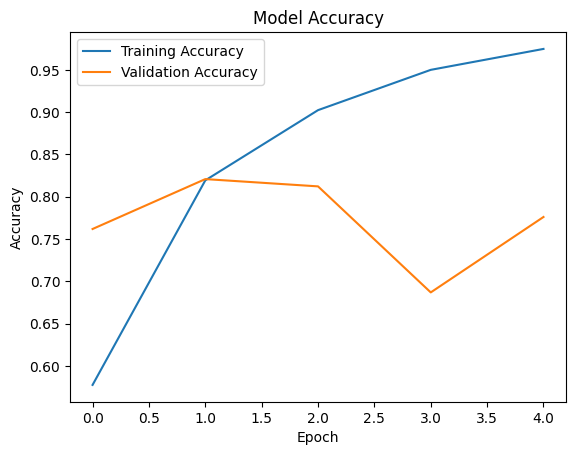

In [ ]:
############
# RNN for Text classification
#
###########
# Import required libraries
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense
import matplotlib.pyplot as plt

# Load IMDB dataset (top 10,000 most frequent words)
vocab_size = 10000
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocab_size)

# Pad sequences so all reviews have the same length
max_length = 200
x_train = pad_sequences(x_train, maxlen=max_length)
x_test = pad_sequences(x_test, maxlen=max_length)

# Build the RNN model
model = Sequential()

# Embedding layer converts word indexes into dense vectors
model.add(Embedding(input_dim=vocab_size, output_dim=32))

# Simple RNN layer for sequential text processing
model.add(SimpleRNN(32))

# Output layer for binary classification (positive / negative)
model.add(Dense(1, activation='sigmoid'))

# Compile the model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train the model
history = model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

# Evaluate model on test data
test_loss, test_acc = model.evaluate(x_test, y_test)

print("Test Accuracy:", test_acc)

# Plot training accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()